# "Human Learning" with iris data

Can you predict the species of an iris using petal and sepal measurements?

TASKS:
1. Read iris data into a pandas DataFrame, including column names.
2. Gather some basic information about the data.
3. Use groupby, sorting, and/or plotting to look for differences between species.
4. Come up with a set of rules that could be used to predict species based upon measurements.

BONUS: Define a function that accepts a row of data and returns a predicted species.
Then, use that function to make predictions for all existing rows of data.

### Introduction to the Iris Dataset

## Task 1

In [3]:
# read the iris data into a pandas DataFrame, including column names

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df=pd.read_csv('iris.csv')

In [11]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [12]:
column_names = ['sepal_length','sepal_width','petal_length','petal_width','species']

In [13]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## Task 2

In [ ]:
# gather basic information

In [14]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [15]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [17]:
df.shape

(150, 5)

In [18]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [19]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [26]:
df.isnull().mean() * 100

sepal_length    0.0
sepal_width     0.0
petal_length    0.0
petal_width     0.0
species         0.0
dtype: float64

In [20]:
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
23,5.1,3.3,1.7,0.5,setosa
122,7.7,2.8,6.7,2.0,virginica
79,5.7,2.6,3.5,1.0,versicolor
90,5.5,2.6,4.4,1.2,versicolor
109,7.2,3.6,6.1,2.5,virginica


In [21]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [22]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [23]:
df.value_counts()

sepal_length  sepal_width  petal_length  petal_width  species  
4.9           3.1          1.5           0.1          setosa       3
5.8           2.7          5.1           1.9          virginica    2
4.3           3.0          1.1           0.1          setosa       1
4.4           3.2          1.3           0.2          setosa       1
4.5           2.3          1.3           0.3          setosa       1
                                                                  ..
7.7           2.6          6.9           2.3          virginica    1
              2.8          6.7           2.0          virginica    1
              3.0          6.1           2.3          virginica    1
              3.8          6.7           2.2          virginica    1
7.9           3.8          6.4           2.0          virginica    1
Name: count, Length: 147, dtype: int64

In [24]:
df.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


In [25]:
df.nunique()

sepal_length    35
sepal_width     23
petal_length    43
petal_width     22
species          3
dtype: int64

## Task 3

### use groupby to look for differences between the species

In [27]:
#Generate descriptive statistics for numerical columns
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [33]:
# Group the data by species and calculate the average sepal length
df.groupby('species').sepal_length.mean()

species
setosa        5.006
versicolor    5.936
virginica     6.588
Name: sepal_length, dtype: float64

In [35]:
# Calculate the average of all four measurements for each species
df.groupby('species')[
    ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
].mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [58]:
df.groupby('species').agg('mean')

,sepal_length,sepal_width,petal_length,petal_width,species_num
species,,,,,
setosa,5.006,3.418,1.464,0.244,0.0
versicolor,5.936,2.770,4.260,1.326,1.0
virginica,6.588,2.974,5.552,2.026,2.0


In [59]:
# Calculate multiple statistics for each species
df.groupby('species').agg(['mean', 'min', 'max'])

sepal_length           sepal_width           petal_length       \
                   mean  min  max        mean  min  max         mean  min   
species                                                                     
setosa            5.006  4.3  5.8       3.418  2.3  4.4        1.464  1.0   
versicolor        5.936  4.9  7.0       2.770  2.0  3.4        4.260  3.0   
virginica         6.588  4.9  7.9       2.974  2.2  3.8        5.552  4.5   

                petal_width           species_num          
            max        mean  min  max        mean min max  
species                                                    
setosa      1.9       0.244  0.1  0.6         0.0   0   0  
versicolor  5.1       1.326  1.0  1.8         1.0   1   1  
virginica   6.9       2.026  1.4  2.5         2.0   2   2

In [38]:
# Generate descriptive statistics for each species separately
df.groupby('species').describe()

sepal_length                                              \
                  count   mean       std  min    25%  50%  75%  max   
species                                                               
setosa             50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
versicolor         50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
virginica          50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

           sepal_width         ... petal_length      petal_width         \
                 count   mean  ...          75%  max       count   mean   
species                        ...                                        
setosa            50.0  3.418  ...        1.575  1.9        50.0  0.244   
versicolor        50.0  2.770  ...        4.600  5.1        50.0  1.326   
virginica         50.0  2.974  ...        5.875  6.9        50.0  2.026   

                                               
                 std  min  25%  50%  75%  max  
species                                        
setosa      0.107210  0.1  0.2  0.2  0.3  0.6  
versicolor  0.197753  1.0  1.2  1.3  1.5  1.8  
virginica   0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]

### use sorting to look for differences between the species

In [39]:
# Sort rows by sepal length in ascending order
df.sort_values(by='sepal_length').values

array([[4.3, 3.0, 1.1, 0.1, 'setosa'],
       [4.4, 2.9, 1.4, 0.2, 'setosa'],
       [4.4, 3.2, 1.3, 0.2, 'setosa'],
       [4.4, 3.0, 1.3, 0.2, 'setosa'],
       [4.5, 2.3, 1.3, 0.3, 'setosa'],
       [4.6, 3.6, 1.0, 0.2, 'setosa'],
       [4.6, 3.1, 1.5, 0.2, 'setosa'],
       [4.6, 3.4, 1.4, 0.3, 'setosa'],
       [4.6, 3.2, 1.4, 0.2, 'setosa'],
       [4.7, 3.2, 1.3, 0.2, 'setosa'],
       [4.7, 3.2, 1.6, 0.2, 'setosa'],
       [4.8, 3.0, 1.4, 0.3, 'setosa'],
       [4.8, 3.1, 1.6, 0.2, 'setosa'],
       [4.8, 3.4, 1.9, 0.2, 'setosa'],
       [4.8, 3.4, 1.6, 0.2, 'setosa'],
       [4.8, 3.0, 1.4, 0.1, 'setosa'],
       [4.9, 2.4, 3.3, 1.0, 'versicolor'],
       [4.9, 3.1, 1.5, 0.1, 'setosa'],
       [4.9, 3.1, 1.5, 0.1, 'setosa'],
       [4.9, 3.0, 1.4, 0.2, 'setosa'],
       [4.9, 3.1, 1.5, 0.1, 'setosa'],
       [4.9, 2.5, 4.5, 1.7, 'virginica'],
       [5.0, 3.5, 1.3, 0.3, 'setosa'],
       [5.0, 3.3, 1.4, 0.2, 'setosa'],
       [5.0, 3.4, 1.6, 0.4, 'setosa'],
       [5.0, 3.4, 

In [40]:
# Sort rows by sepal width in ascending order
df.sort_values(by='sepal_width').values

array([[5.0, 2.0, 3.5, 1.0, 'versicolor'],
       [6.0, 2.2, 4.0, 1.0, 'versicolor'],
       [6.0, 2.2, 5.0, 1.5, 'virginica'],
       [6.2, 2.2, 4.5, 1.5, 'versicolor'],
       [6.3, 2.3, 4.4, 1.3, 'versicolor'],
       [5.0, 2.3, 3.3, 1.0, 'versicolor'],
       [5.5, 2.3, 4.0, 1.3, 'versicolor'],
       [4.5, 2.3, 1.3, 0.3, 'setosa'],
       [4.9, 2.4, 3.3, 1.0, 'versicolor'],
       [5.5, 2.4, 3.8, 1.1, 'versicolor'],
       [5.5, 2.4, 3.7, 1.0, 'versicolor'],
       [6.3, 2.5, 4.9, 1.5, 'versicolor'],
       [5.6, 2.5, 3.9, 1.1, 'versicolor'],
       [5.1, 2.5, 3.0, 1.1, 'versicolor'],
       [6.7, 2.5, 5.8, 1.8, 'virginica'],
       [4.9, 2.5, 4.5, 1.7, 'virginica'],
       [5.7, 2.5, 5.0, 2.0, 'virginica'],
       [5.5, 2.5, 4.0, 1.3, 'versicolor'],
       [6.3, 2.5, 5.0, 1.9, 'virginica'],
       [5.8, 2.6, 4.0, 1.2, 'versicolor'],
       [5.5, 2.6, 4.4, 1.2, 'versicolor'],
       [7.7, 2.6, 6.9, 2.3, 'virginica'],
       [6.1, 2.6, 5.6, 1.4, 'virginica'],
       [5.7, 2.6, 3.5,

In [41]:
# Sort rows by petal length in ascending order
df.sort_values(by='petal_length').values

array([[4.6, 3.6, 1.0, 0.2, 'setosa'],
       [4.3, 3.0, 1.1, 0.1, 'setosa'],
       [5.8, 4.0, 1.2, 0.2, 'setosa'],
       [5.0, 3.2, 1.2, 0.2, 'setosa'],
       [5.4, 3.9, 1.3, 0.4, 'setosa'],
       [4.4, 3.0, 1.3, 0.2, 'setosa'],
       [5.5, 3.5, 1.3, 0.2, 'setosa'],
       [4.7, 3.2, 1.3, 0.2, 'setosa'],
       [5.0, 3.5, 1.3, 0.3, 'setosa'],
       [4.5, 2.3, 1.3, 0.3, 'setosa'],
       [4.4, 3.2, 1.3, 0.2, 'setosa'],
       [5.1, 3.5, 1.4, 0.3, 'setosa'],
       [4.8, 3.0, 1.4, 0.1, 'setosa'],
       [4.4, 2.9, 1.4, 0.2, 'setosa'],
       [4.6, 3.4, 1.4, 0.3, 'setosa'],
       [5.1, 3.5, 1.4, 0.2, 'setosa'],
       [5.5, 4.2, 1.4, 0.2, 'setosa'],
       [4.8, 3.0, 1.4, 0.3, 'setosa'],
       [4.9, 3.0, 1.4, 0.2, 'setosa'],
       [5.0, 3.6, 1.4, 0.2, 'setosa'],
       [5.2, 3.4, 1.4, 0.2, 'setosa'],
       [4.6, 3.2, 1.4, 0.2, 'setosa'],
       [5.0, 3.3, 1.4, 0.2, 'setosa'],
       [5.1, 3.8, 1.5, 0.3, 'setosa'],
       [5.1, 3.7, 1.5, 0.4, 'setosa'],
       [5.4, 3.4, 1.5, 0.

In [42]:
# Sort rows by petal width in ascending order
df.sort_values(by='petal_width').values

array([[4.8, 3.0, 1.4, 0.1, 'setosa'],
       [4.3, 3.0, 1.1, 0.1, 'setosa'],
       [4.9, 3.1, 1.5, 0.1, 'setosa'],
       [5.2, 4.1, 1.5, 0.1, 'setosa'],
       [4.9, 3.1, 1.5, 0.1, 'setosa'],
       [4.9, 3.1, 1.5, 0.1, 'setosa'],
       [5.0, 3.6, 1.4, 0.2, 'setosa'],
       [5.1, 3.5, 1.4, 0.2, 'setosa'],
       [4.8, 3.4, 1.6, 0.2, 'setosa'],
       [5.4, 3.7, 1.5, 0.2, 'setosa'],
       [5.0, 3.4, 1.5, 0.2, 'setosa'],
       [4.4, 2.9, 1.4, 0.2, 'setosa'],
       [5.8, 4.0, 1.2, 0.2, 'setosa'],
       [4.9, 3.0, 1.4, 0.2, 'setosa'],
       [4.7, 3.2, 1.3, 0.2, 'setosa'],
       [4.6, 3.1, 1.5, 0.2, 'setosa'],
       [5.2, 3.4, 1.4, 0.2, 'setosa'],
       [5.2, 3.5, 1.5, 0.2, 'setosa'],
       [5.0, 3.0, 1.6, 0.2, 'setosa'],
       [4.8, 3.1, 1.6, 0.2, 'setosa'],
       [4.8, 3.4, 1.9, 0.2, 'setosa'],
       [5.1, 3.8, 1.6, 0.2, 'setosa'],
       [4.6, 3.2, 1.4, 0.2, 'setosa'],
       [4.4, 3.2, 1.3, 0.2, 'setosa'],
       [5.1, 3.4, 1.5, 0.2, 'setosa'],
       [4.4, 3.0, 1.3, 0.

### use plotting to look for differences between the species

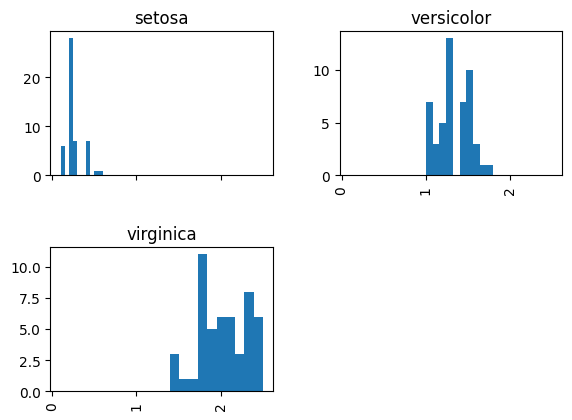

In [43]:
# Import Matplotlib for plotting
import matplotlib.pyplot as plt

# Plot petal width distributions separately for each species
df.hist(column='petal_width', by='species', sharex=True)

# Display the plots
plt.show()

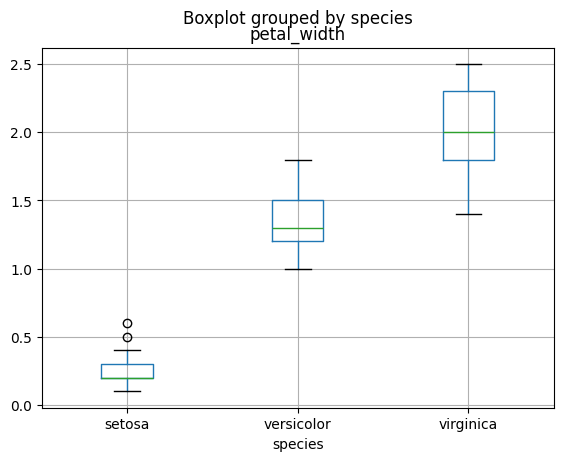

In [44]:
# Create a box plot of petal width grouped by species
df.boxplot(column='petal_width', by='species')

# Display the plot
plt.show()

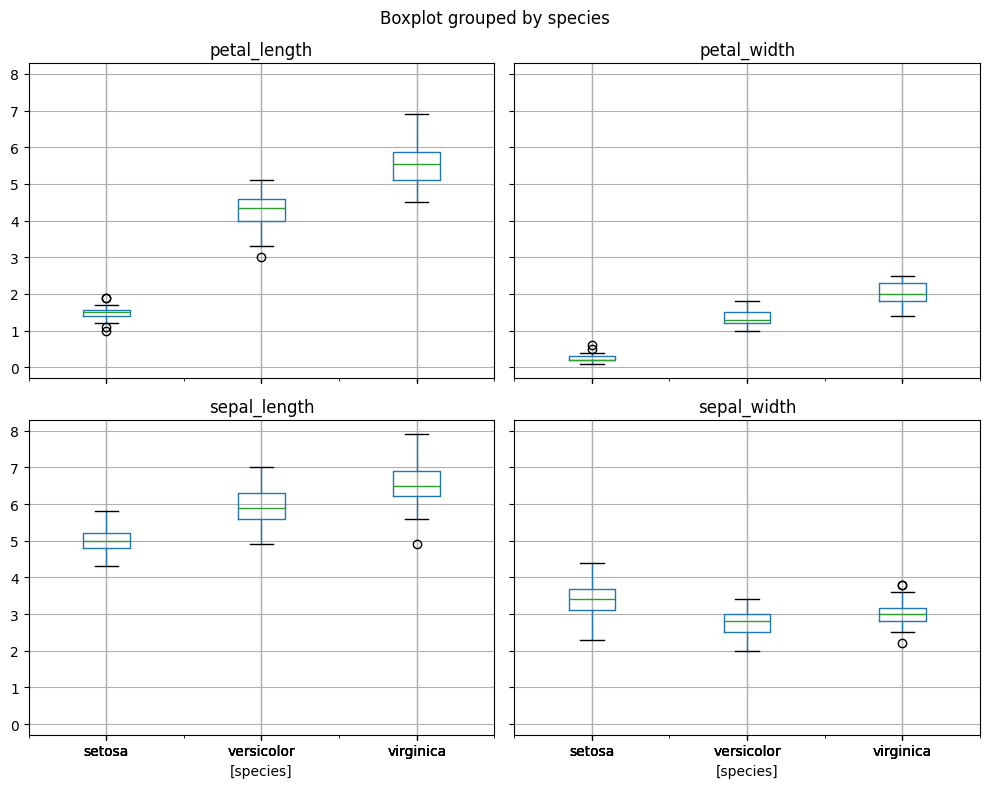

In [45]:
# Compare all numerical measurements across species using box plots
df.boxplot(by='species', layout=(2, 2), figsize=(10, 8))

# Adjust the layout to prevent overlapping labels
plt.tight_layout()

# Display the plots
plt.show()

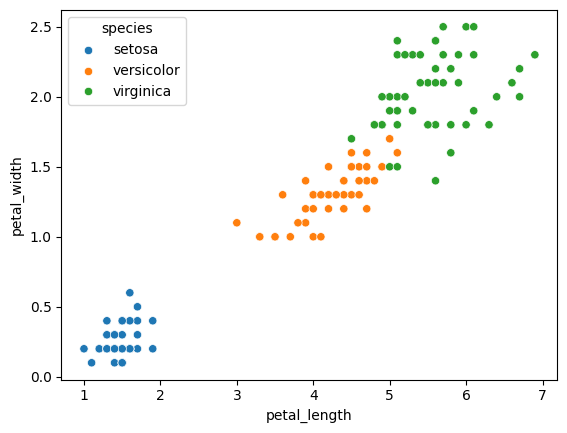

In [51]:
# Import Seaborn for data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot colored by species
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species'
)

# Display the plot
plt.show()

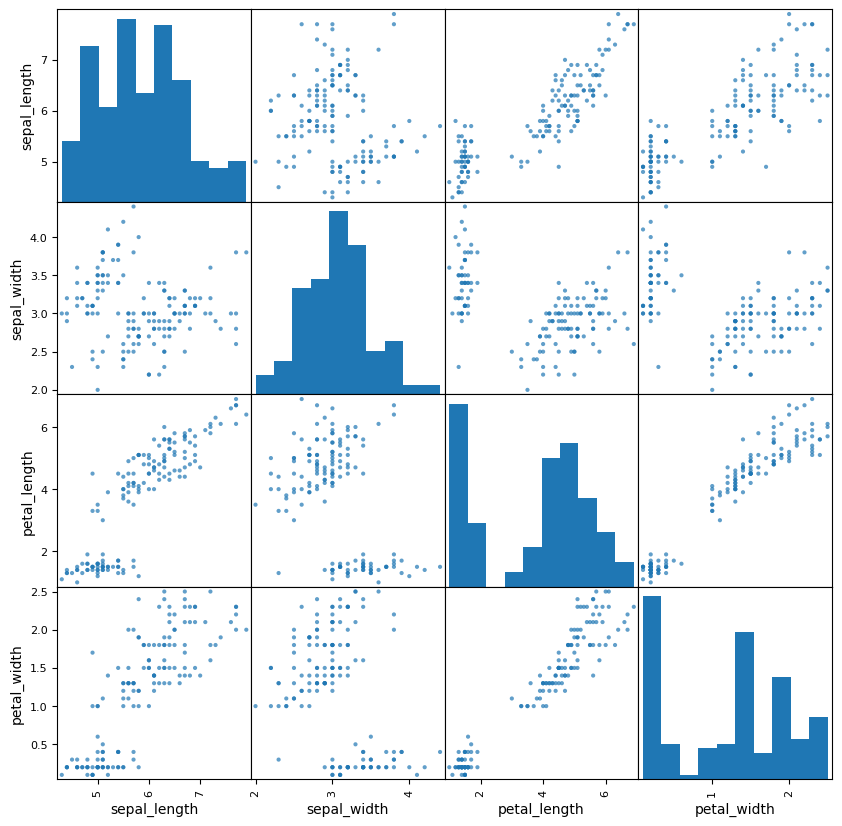

In [52]:
# Import the scatter matrix function from Pandas
from pandas.plotting import scatter_matrix

# Select only numerical columns
numeric_df = df.select_dtypes(include='number')

# Create scatter plots for pairs of numerical features
scatter_matrix(
    numeric_df,
    figsize=(10, 10),
    diagonal='hist',
    alpha=0.7
)

# Display the plots
plt.show()

### map species to a numeric value so that plots can be colored by category

In [62]:
# Map each species to a numeric value
species_mapping = { 'setosa': 0, 'versicolor': 1, 'virginica': 2}

# Create a new column with numeric species labels
df['species_num'] = df['species'].map(species_mapping)

# Display the first five rows
df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species,species_num
146,6.3,2.5,5.0,1.9,virginica,2
13,4.3,3.0,1.1,0.1,setosa,0
98,5.1,2.5,3.0,1.1,versicolor,1
120,6.9,3.2,5.7,2.3,virginica,2
65,6.7,3.1,4.4,1.4,versicolor,1


## Task 4

## Bonus

In [55]:
# define function that accepts a row of data and returns a predicted species

In [56]:
def classify_iris(data):
    if data[col_ix['petal_length']] < 3:
        return 'setosa'
    elif data[col_ix['petal_width']] < 1.8:
        return 'versicolor'
    else:
        return 'virginica'

# make predictions and store as numpy array
preds = np.array([classify_iris(row) for row in df.values])

# calculate the accuracy of the predictions
np.mean(preds == df.species.values)

np.float64(0.96)